2026-04-14 02:53:23,526 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-14 02:53:23,526 - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-14 02:53:25,823 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-04-14 02:53:25,823 - INFO - sklearn.KMeans initialization complete.
2026-04-14 02:53:25,909 - harmonypy - INFO - Iteration 1 of 10
2026-04-14 02:53:25,909 - INFO - Iteration 1 of 10
2026-04-14 02:53:29,128 - harmonypy - INFO - Iteration 2 of 10
2026-04-14 02:53:29,128 - INFO - Iteration 2 of 10
2026-04-14 02:53:32,312 - harmonypy - INFO - Iteration 3 of 10
2026-04-14 02:53:32,312 - INFO - Iteration 3 of 10
2026-04-14 02:53:35,510 - harmonypy - INFO - Converged after 3 iterations
2026-04-14 02:53:35,510 - INFO - Converged after 3 iterations
... storing 'labels' as categorical
... storing 'batch' as categorical


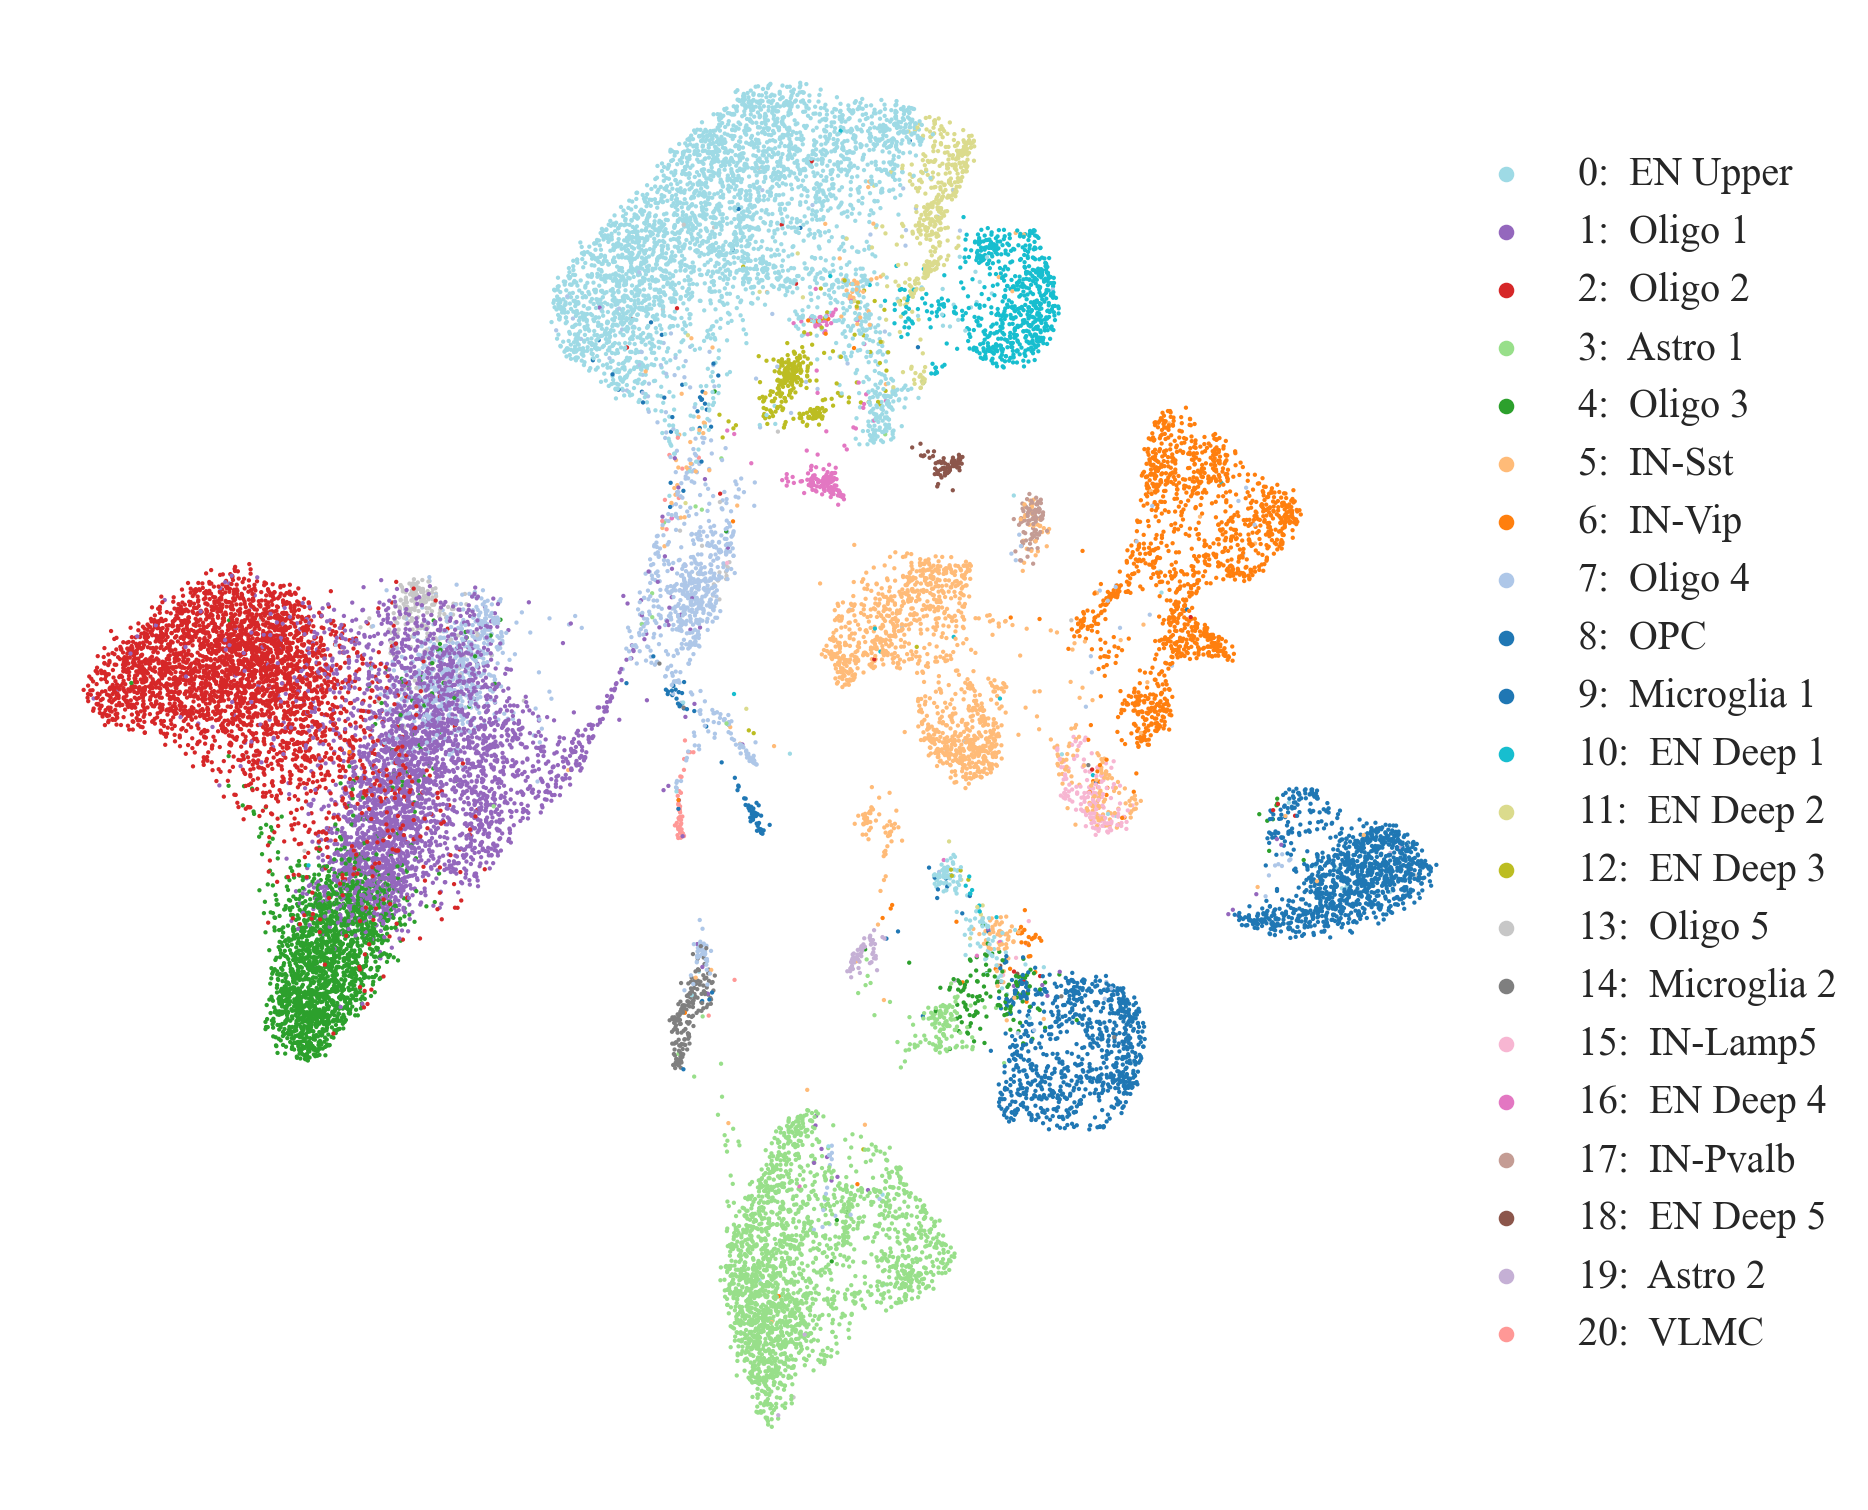

In [2]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import seaborn as sns
import celloracle as co
import scanpy.external as sce
import matplotlib.pyplot as plt
%matplotlib inline


plt.rcParams["font.family"] = "Times New Roman"
sc.set_figure_params(scanpy = False)


workdir = "./ComicGTN/data/MOGHE_brain"
RNA_seq = sc.read(os.path.join(workdir, "Gene_Cell.mtx"))
Cell_names = pd.read_csv(os.path.join(workdir, "Cell_names.tsv"), sep = "\t", header = None)
Gene_names = pd.read_csv(os.path.join(workdir, "Gene_names.tsv"), sep = "\t", header = None)
RNA_count = RNA_seq.X


adata =  ad.AnnData(RNA_count.transpose(), dtype = "int32")
adata.obs_names = Cell_names[0]
adata.var_names = Gene_names[0]
adata.var_names_make_unique()
sc.pp.normalize_total(adata, target_sum = 1e4)
filter_result = sc.pp.filter_genes_dispersion(adata.X, flavor = "cell_ranger", n_top_genes = 2000, log = False)
gene_subset = filter_result.gene_subset
gene_subset[Gene_names.isin(["RORB", "RORC"])[0]] = True
adata = adata[:, gene_subset]
sc.pp.normalize_per_cell(adata)
adata.raw = adata
adata.layers["raw_count"] = adata.raw.X.copy()
sc.pp.log1p(adata)
sc.pp.scale(adata, max_value = 10)


pred_labels = pd.read_csv(os.path.join(workdir, "ComicGTN_pred.tsv"), sep = "\t", header = None)
labels = pred_labels[0].tolist()
samples = pd.read_csv(os.path.join(workdir, "Sample_ids.tsv"), sep = "\t", header = None)
samples = samples[0].tolist()
adata.obs["labels"] = labels
adata.obs["labels"] = adata.obs["labels"].astype("str")
adata.obs["batch"] = samples
adata.obs["batch"] = adata.obs["batch"].astype("str")
cell_type_dict = {"0": "0:  EN Upper", "1": "1:  Oligo 1", "2": "2:  Oligo 2", "3": "3:  Astro 1", "4": "4:  Oligo 3", "5": "5:  IN-Sst", "6": "6:  IN-Vip", 
                           "7": "7:  Oligo 4", "8": "8:  OPC", "9": "9:  Microglia 1", "10": "10:  EN Deep 1", "11": "11:  EN Deep 2", "12": "12:  EN Deep 3", 
                           "13": "13:  Oligo 5", "14": "14:  Microglia 2", "15": "15:  IN-Lamp5", "16": "16:  EN Deep 4", "17": "17:  IN-Pvalb", 
                           "18": "18:  EN Deep 5", "19": "19:  Astro 2", "20": "20:  VLMC"}
adata.obs["cell_types"] = adata.obs["labels"].map(cell_type_dict)
adata.obs["cell_types"] = adata.obs["cell_types"].astype("category")


sc.pp.pca(adata)
sce.pp.harmony_integrate(adata, "batch")
sc.pp.neighbors(adata, n_neighbors = 20, n_pcs = 30, use_rep = "X_pca_harmony")
sc.tl.umap(adata)


fig, ax = plt.subplots(figsize = (12, 12))
sc.pl.umap(adata, size = 15, color = ["cell_types"], palette = "tab20_r", title = "", frameon = False, ax = ax, show = False)
handles, labels = ax.get_legend_handles_labels()
desired_order = ["0:  EN Upper", "1:  Oligo 1", "2:  Oligo 2", "3:  Astro 1", "4:  Oligo 3", "5:  IN-Sst", "6:  IN-Vip", 
                            "7:  Oligo 4", "8:  OPC", "9:  Microglia 1", "10:  EN Deep 1", "11:  EN Deep 2", "12:  EN Deep 3", 
                            "13:  Oligo 5", "14:  Microglia 2", "15:  IN-Lamp5", "16:  EN Deep 4", "17:  IN-Pvalb", 
                            "18:  EN Deep 5", "19:  Astro 2", "20:  VLMC"]
ordered_handles = []
ordered_labels = []

for label in desired_order:
    if label in labels:
        idx = labels.index(label)
        ordered_handles.append(handles[idx])
        ordered_labels.append(labels[idx])

ax.get_legend().remove()
ax.legend(ordered_handles, ordered_labels, loc = "center left", bbox_to_anchor = (0.95, 0.5), ncol = 1, fontsize = 18, frameon = False)

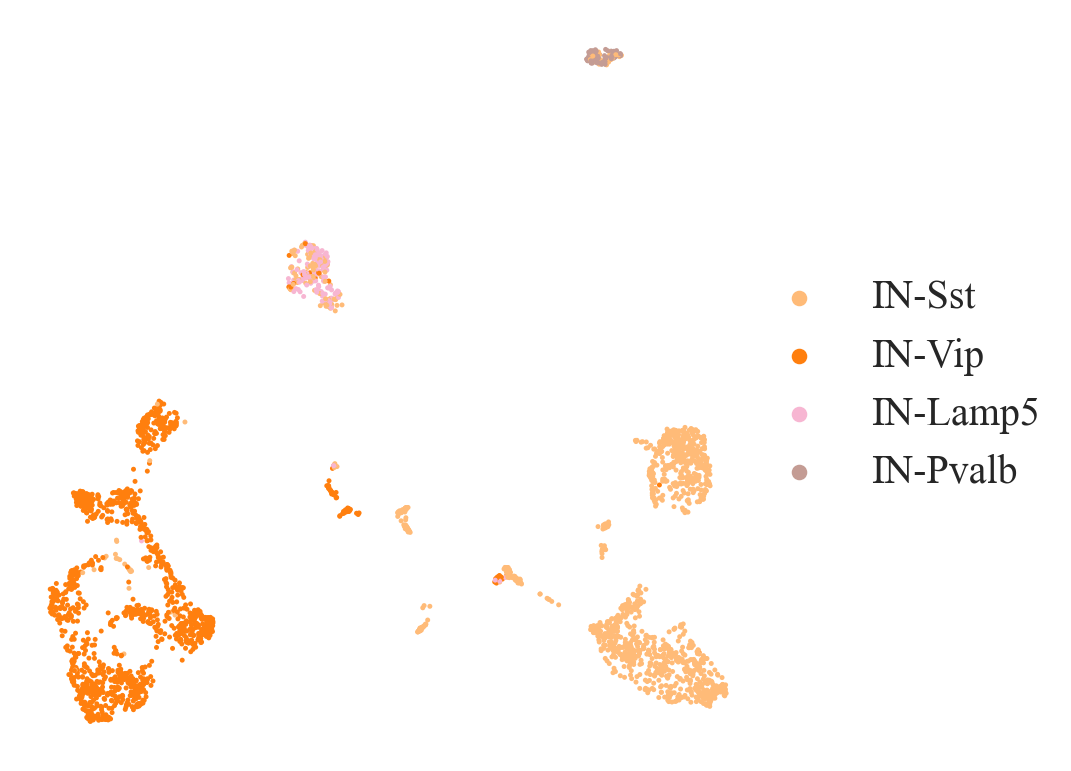

In [3]:
order = ["5", "6", "15", "17"]
adata1 = adata[adata.obs["labels"].isin(order), :].copy()
adata1.var_names_make_unique()
IN_type_dict = {"5:  IN-Sst": "IN-Sst", "6:  IN-Vip": "IN-Vip", "15:  IN-Lamp5": "IN-Lamp5", "17:  IN-Pvalb": "IN-Pvalb"}
IN_cluster_dict = {"5": "0", "6": "1", "15": "2", "17": "3"}
adata1.obs["cell_types"] = adata1.obs["cell_types"].map(IN_type_dict)
adata1.obs["labels"] = adata1.obs["labels"].map(IN_cluster_dict)
# adata1.write_h5ad(os.path.join(workdir, "Neuron_type/IN_cluster.h5ad"))
color_dict = {"IN-Sst": "#FFBB78", "IN-Vip": "#FF7F0E", "IN-Lamp5": "#F7B6D2", "IN-Pvalb": "#C49C94"}


sc.pp.neighbors(adata1, n_neighbors = 20, n_pcs = 30, use_rep = "X_pca_harmony")
sc.tl.umap(adata1,min_dist = 0.1)
fig, ax = plt.subplots(figsize = (6, 6))
sc.pl.umap(adata1, size = 20, color = ["cell_types"], palette = color_dict, title = "", frameon = False, ax = ax, show = False)
handles, labels = ax.get_legend_handles_labels()
desired_order = ["IN-Sst", "IN-Vip", "IN-Lamp5", "IN-Pvalb"]
ordered_handles = []
ordered_labels = []

for label in desired_order:
    if label in labels:
        idx = labels.index(label)
        ordered_handles.append(handles[idx])
        ordered_labels.append(labels[idx])

ax.get_legend().remove()
ax.legend(ordered_handles, ordered_labels, loc = "center left", bbox_to_anchor = (0.95, 0.5), fontsize = 18, frameon = False)

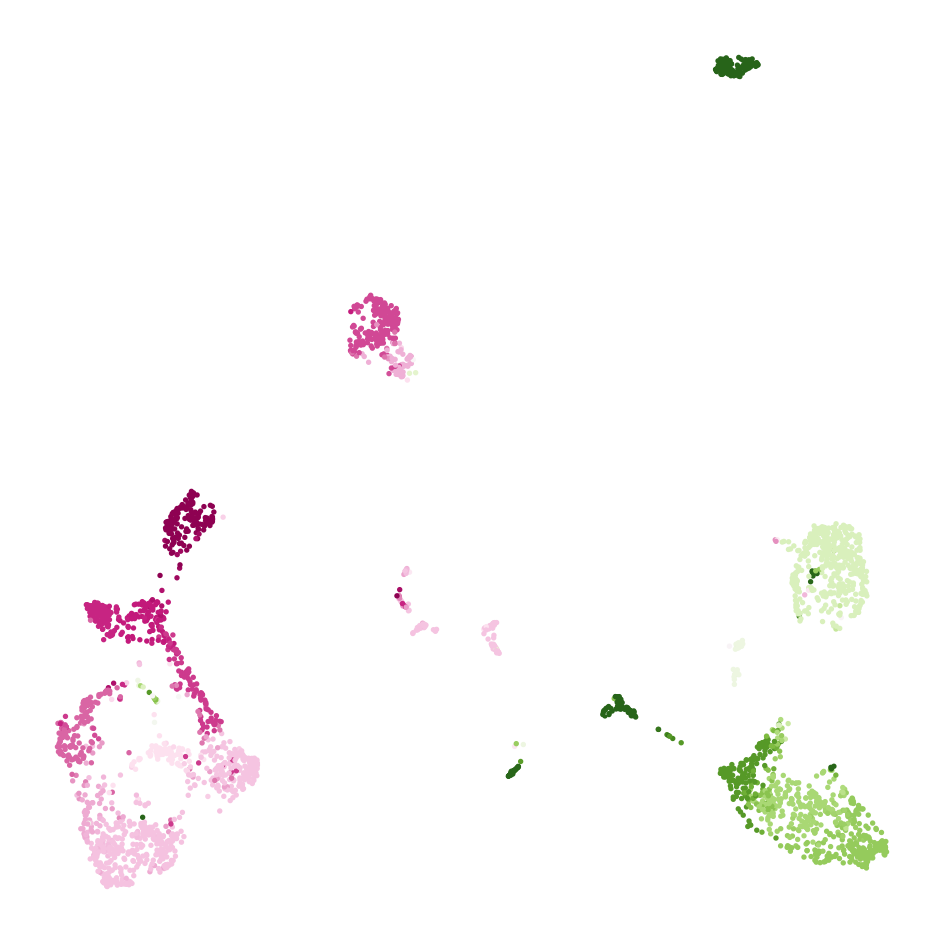

In [4]:
pseudotime = pd.read_csv(os.path.join(workdir, "Neuron_type/Pseudo_time.tsv"), sep = "\t", header = None)
pseudotime_values = pseudotime[0]
umap_coords = adata1.obsm["X_umap"]


fig, ax = plt.subplots(figsize = (6, 6))
scatter = ax.scatter(umap_coords[:, 0], umap_coords[:, 1], c = pseudotime_values, cmap = "PiYG", s = 2, alpha = 1.0)
ax.set_xticks([])
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)


plt.tight_layout()
plt.show()

Loading prebuilt promoter base-GRN. Version: hg19_gimmemotifsv5_fpr2


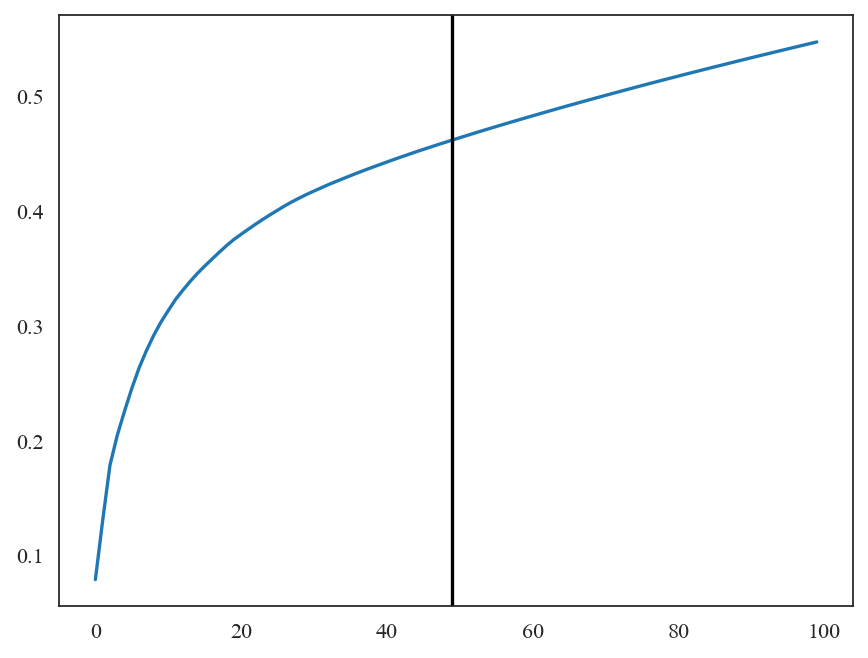

49


  0%|          | 0/4 [00:00<?, ?it/s]

Inferring GRN for IN-Lamp5...


  0%|          | 0/1615 [00:00<?, ?it/s]

Inferring GRN for IN-Pvalb...


...

Inferring GRN for IN-Sst...


  0%|          | 0/1615 [00:00<?, ?it/s]

Inferring GRN for IN-Vip...


  0%|          | 0/1615 [00:00<?, ?it/s]

IN-Lamp5


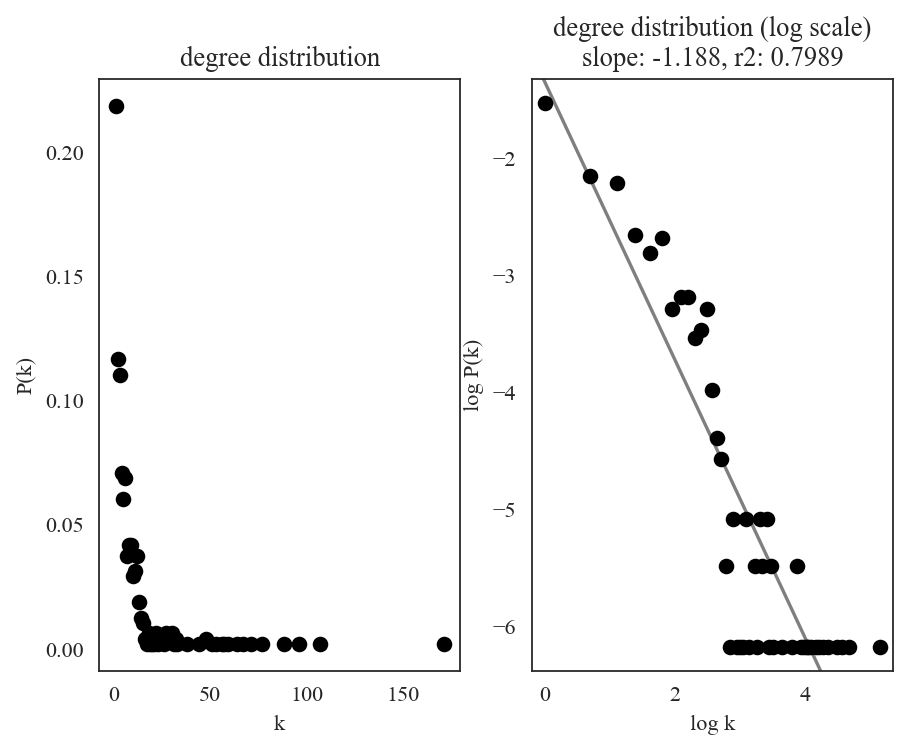

IN-Pvalb


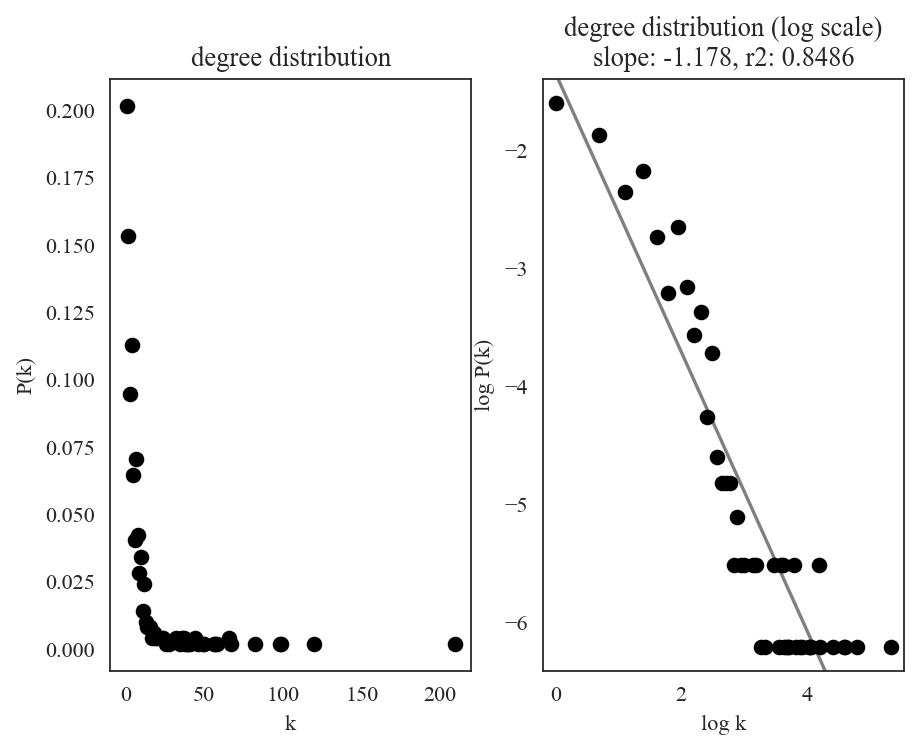

IN-Sst


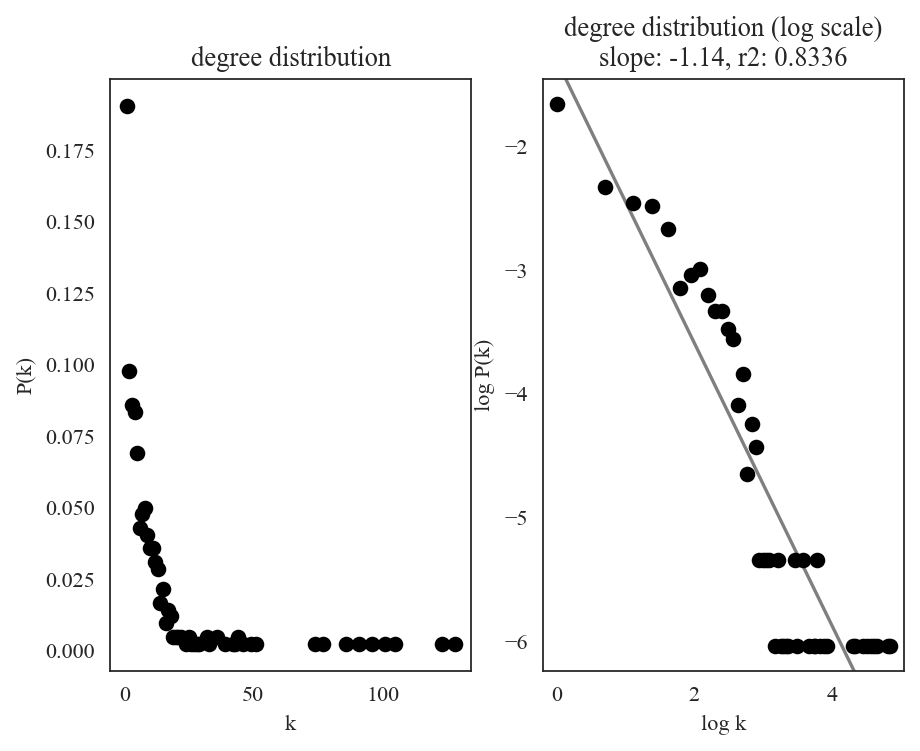

IN-Vip


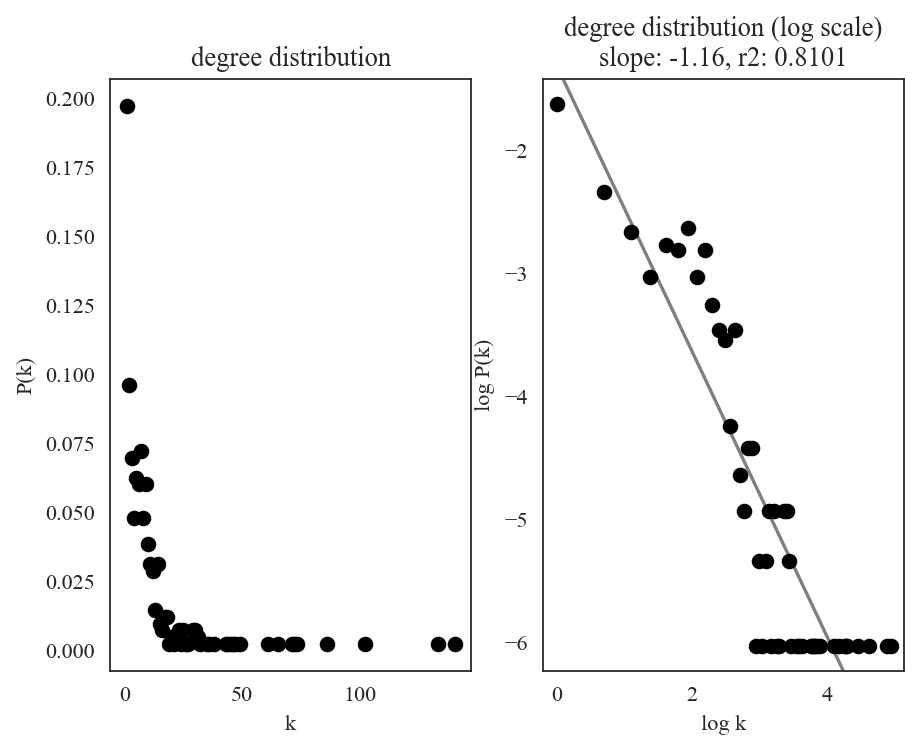

In [8]:
base_GRN = co.data.load_human_promoter_base_GRN()
base_GRN.head()
oracle = co.Oracle()
adata1.X = adata1.layers["raw_count"].copy()
oracle.import_anndata_as_raw_count(adata = adata1, cluster_column_name = "cell_types", embedding_name = "X_umap")
oracle.import_TF_data(TF_info_matrix = base_GRN)
oracle.perform_PCA()


plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_)) > 0.002))[0][0]
plt.axvline(n_comps, c = "k")
plt.show()
print(n_comps)
n_comps = min(n_comps, 50)


n_cell = oracle.adata.shape[0]
k = int(0.025 * n_cell)
oracle.knn_imputation(n_pca_dims = n_comps, k = k, balanced = True, b_sight = k * 8, b_maxl = k * 4, n_jobs = 4)
oracle.to_hdf5(os.path.join(workdir, "Neuron_type/IN_cluster.celloracle.oracle"))
links = oracle.get_links(cluster_name_for_GRN_unit = "cell_types", alpha = 10, verbose_level = 10)
links.filter_links(p = 0.001, weight = "coef_abs", threshold_number = 2000)
links.plot_degree_distributions(plot_model = True)
links.get_network_score()
# links.to_hdf5(os.path.join(workdir, "Neuron_type/IN_cluster.celloracle.links"))

  0%|          | 0/4 [00:00<?, ?it/s]

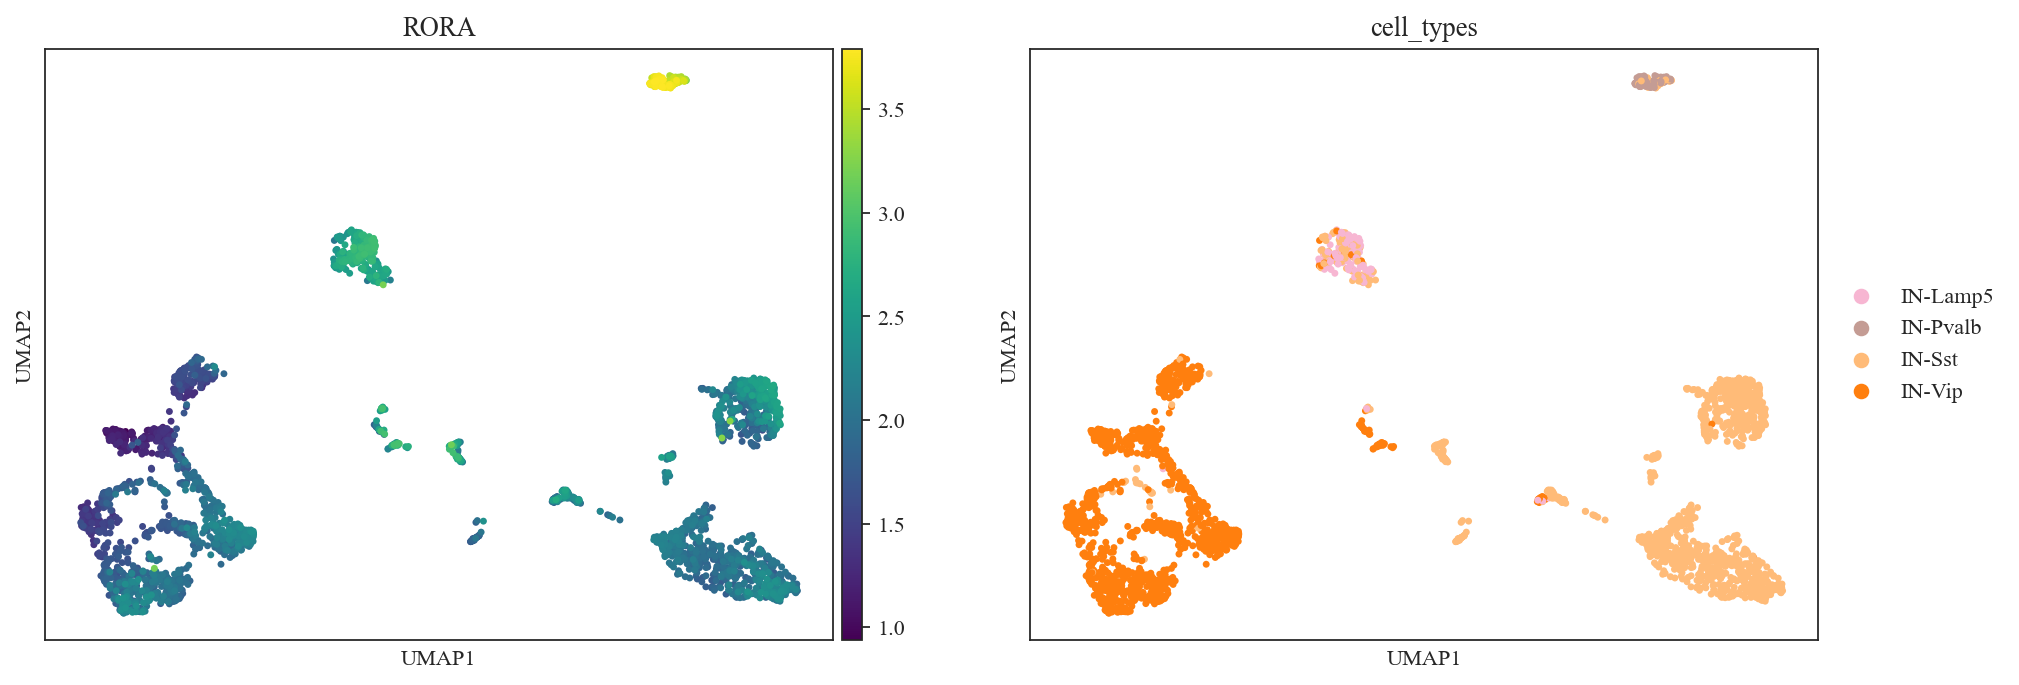

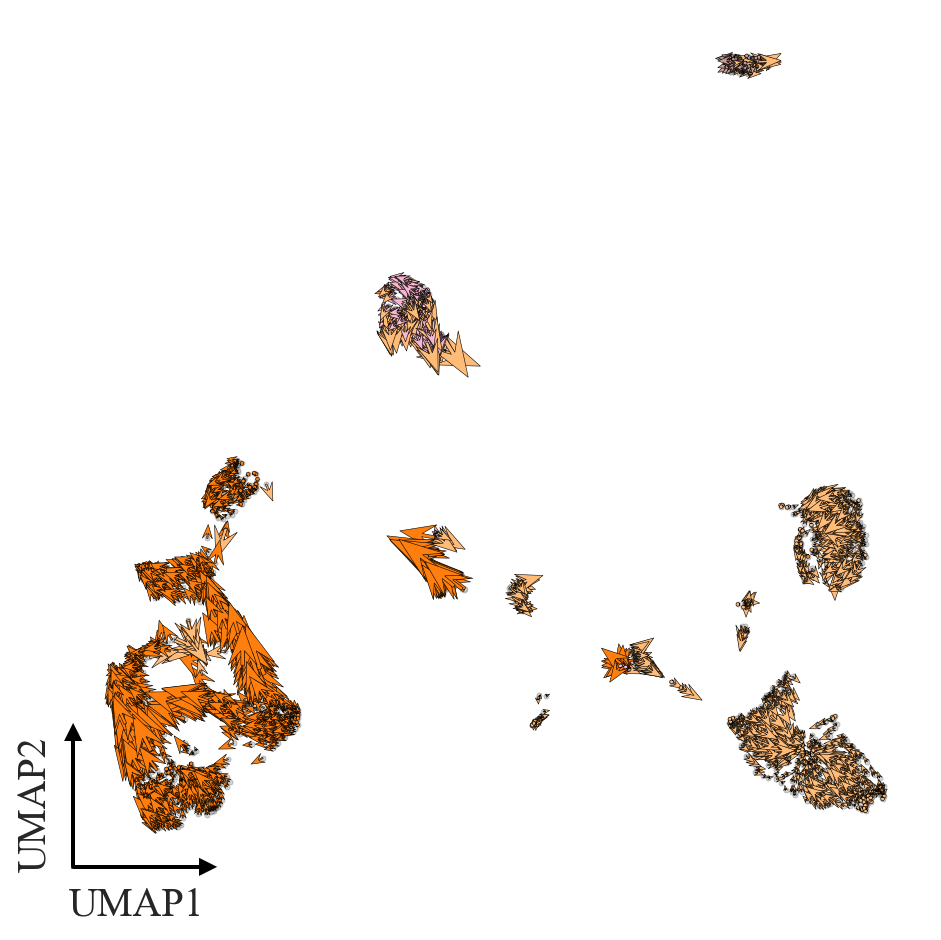

In [14]:
oracle.get_cluster_specific_TFdict_from_Links(links_object = links)
oracle.fit_GRN_for_simulation(alpha = 10, use_cluster_specific_TFdict = True)
goi = "RORA"
sc.pl.umap(oracle.adata, color = [goi, oracle.cluster_column_name], layer = "imputed_count", use_raw = False, cmap = "viridis")
oracle.simulate_shift(perturb_condition = {goi: 0.0}, n_propagation = 3)
oracle.estimate_transition_prob(n_neighbors = 200, knn_random = True, sampled_fraction = 1)
oracle.calculate_embedding_shift(sigma_corr = 0.05)

fig, ax = plt.subplots(figsize = (6, 6))
oracle.plot_quiver(scale = 25, ax = ax)
ax = plt.gca()
ax.set_xlabel("UMAP1", fontsize = 18)
ax.set_ylabel("UMAP2", fontsize = 18)


x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
x_range = x_max - x_min
y_range = y_max - y_min
aspect_ratio = (fig.get_size_inches()[0] / fig.get_size_inches()[1]) * (y_range / x_range)
dx = x_range * 0.15 * aspect_ratio
dy = y_range * 0.15 * aspect_ratio
head_width = dy * 0.1
head_length = dx * 0.1
ax.arrow(x_min, y_min, dx, 0, head_width = head_width, head_length = head_length, fc = "black", ec = "black", linewidth = 1.5)
ax.arrow(x_min, y_min, 0, dy, head_width = head_width, head_length = head_length, fc = "black", ec = "black", linewidth = 1.5)


label_offset = dx * 0.15
ax.text(x_min + dx / 2, y_min - label_offset, "UMAP1", ha = "center", va = "top", fontsize = 18)
ax.text(x_min - label_offset, y_min + dy / 2, "UMAP2", rotation = 90, ha = "right", va = "center", fontsize = 18)
plt.tight_layout()
plt.savefig("/home/jsl/YBR/Ex2/Figure/Figure4-k.png", dpi = 600, bbox_inches = "tight")
plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]

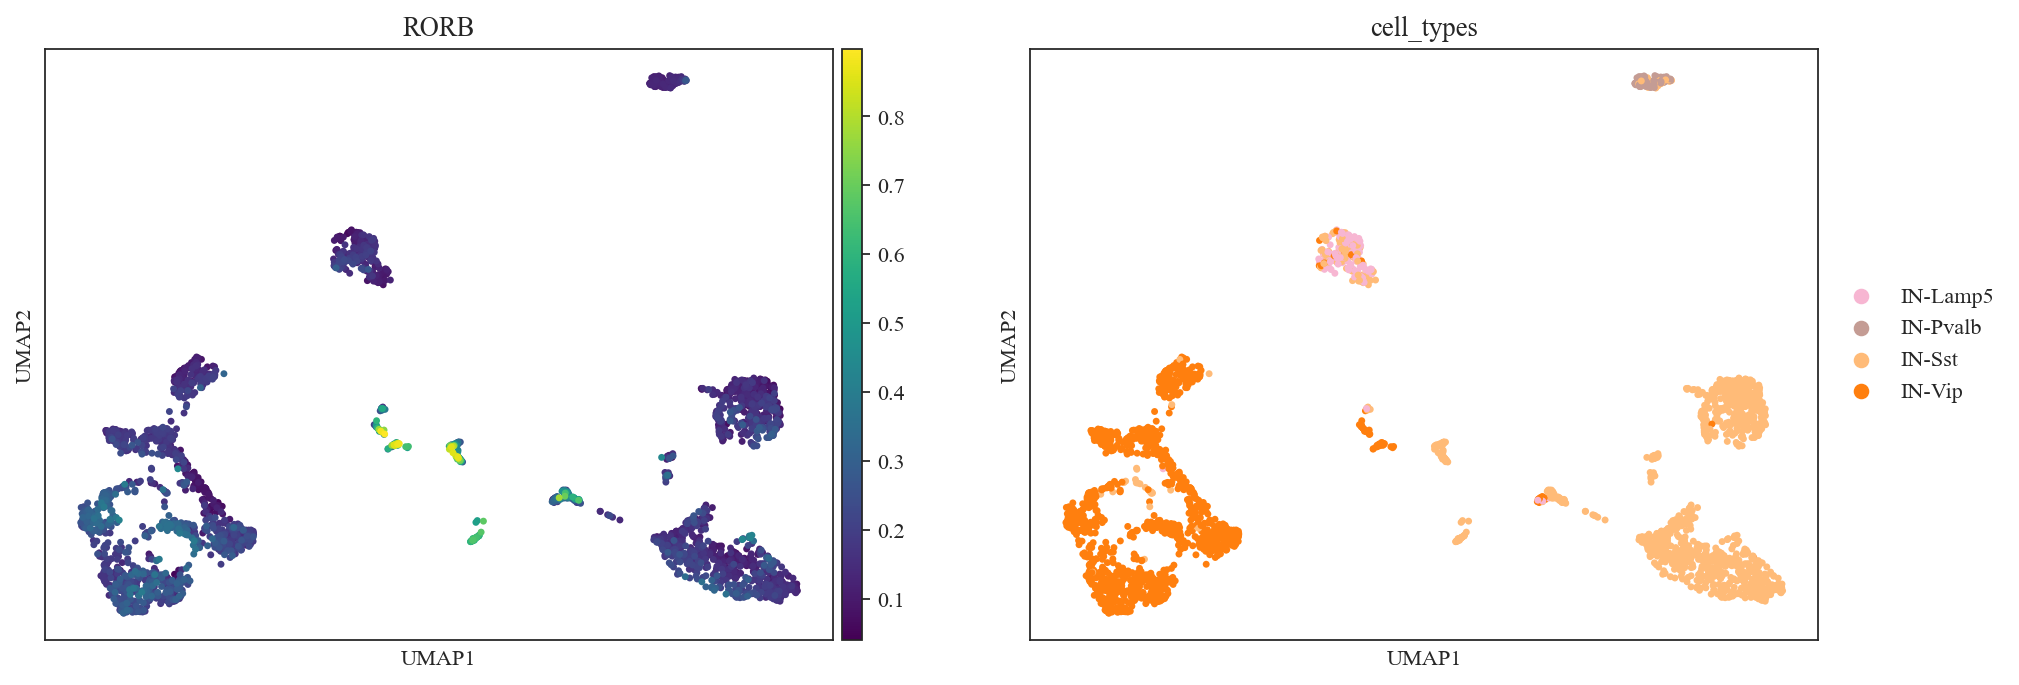

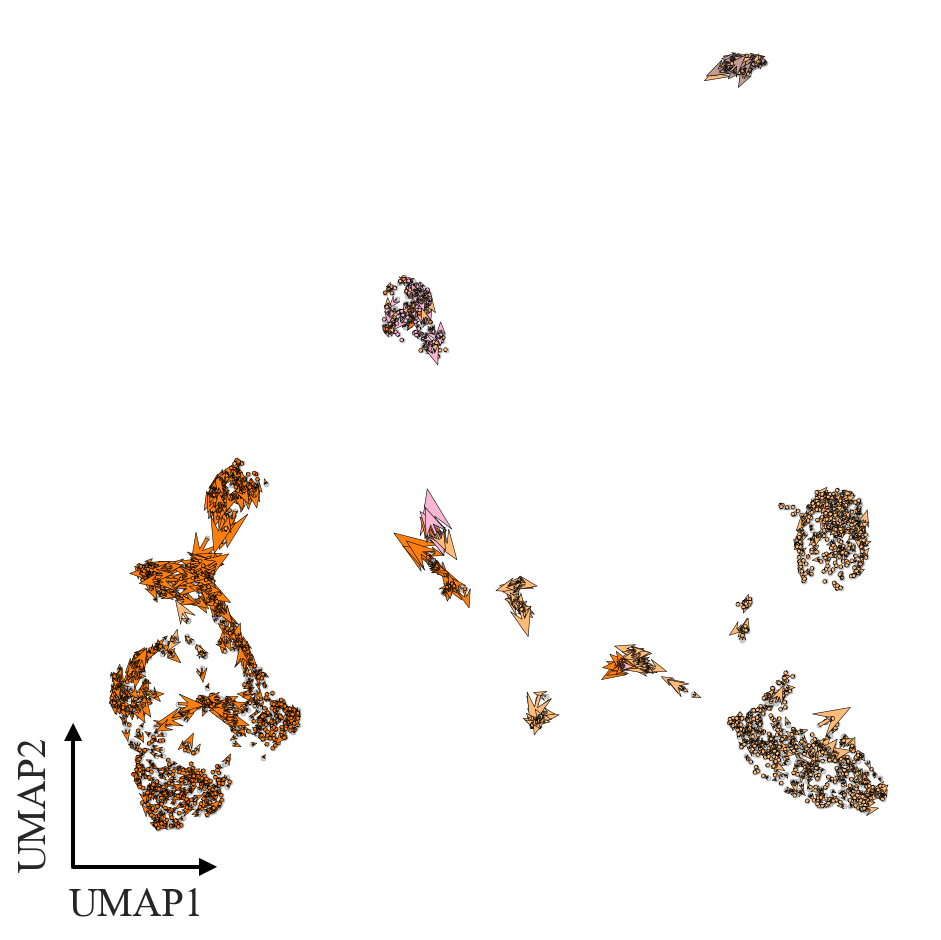

In [15]:
oracle.get_cluster_specific_TFdict_from_Links(links_object = links)
oracle.fit_GRN_for_simulation(alpha = 10, use_cluster_specific_TFdict = True)
goi = "RORB"
sc.pl.umap(oracle.adata, color = [goi, oracle.cluster_column_name], layer = "imputed_count", use_raw = False, cmap = "viridis")
oracle.simulate_shift(perturb_condition = {goi: 0.0}, n_propagation = 3)
oracle.estimate_transition_prob(n_neighbors = 200, knn_random = True, sampled_fraction = 1)
oracle.calculate_embedding_shift(sigma_corr = 0.05)

fig, ax = plt.subplots(figsize = (6, 6))
oracle.plot_quiver_random(scale = 20, ax = ax)
ax = plt.gca()
ax.set_xlabel("UMAP1", fontsize = 18)
ax.set_ylabel("UMAP2", fontsize = 18)


x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
x_range = x_max - x_min
y_range = y_max - y_min
aspect_ratio = (fig.get_size_inches()[0] / fig.get_size_inches()[1]) * (y_range / x_range)
dx = x_range * 0.15 * aspect_ratio
dy = y_range * 0.15 * aspect_ratio
head_width = dy * 0.1
head_length = dx * 0.1
ax.arrow(x_min, y_min, dx, 0, head_width = head_width, head_length = head_length, fc = "black", ec = "black", linewidth = 1.5)
ax.arrow(x_min, y_min, 0, dy, head_width = head_width, head_length = head_length, fc = "black", ec = "black", linewidth = 1.5)


label_offset = dx * 0.15
ax.text(x_min + dx / 2, y_min - label_offset, "UMAP1", ha = "center", va = "top", fontsize = 18)
ax.text(x_min - label_offset, y_min + dy / 2, "UMAP2", rotation = 90, ha = "right", va = "center", fontsize = 18)
plt.tight_layout()
plt.savefig("/home/jsl/YBR/Ex2/Figure/Supplement-Figure13-b.png", dpi = 600, bbox_inches = "tight")
plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]

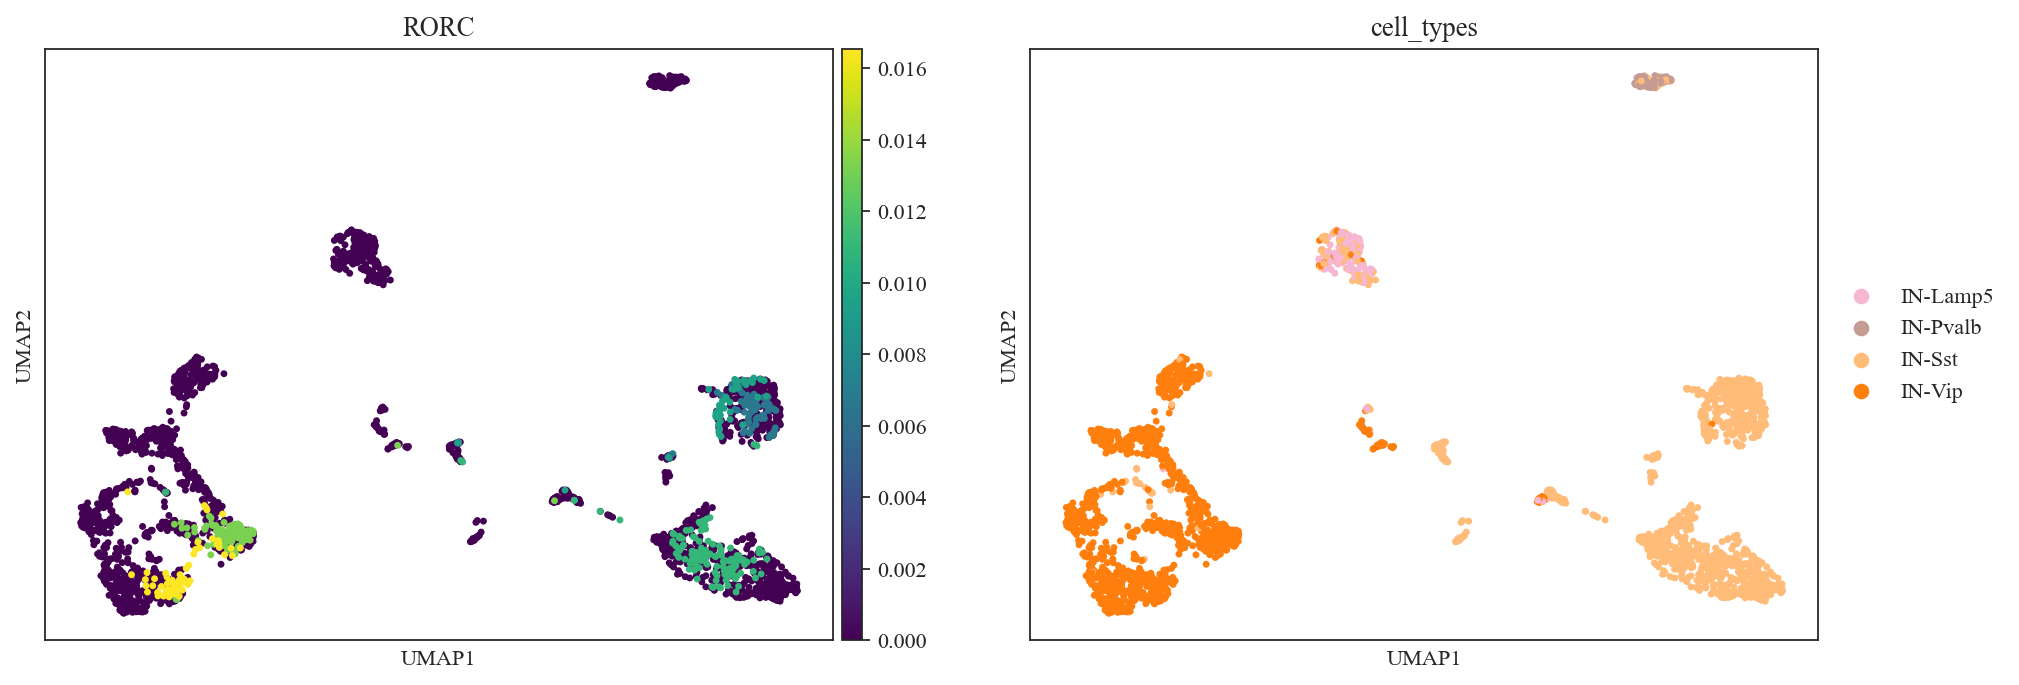

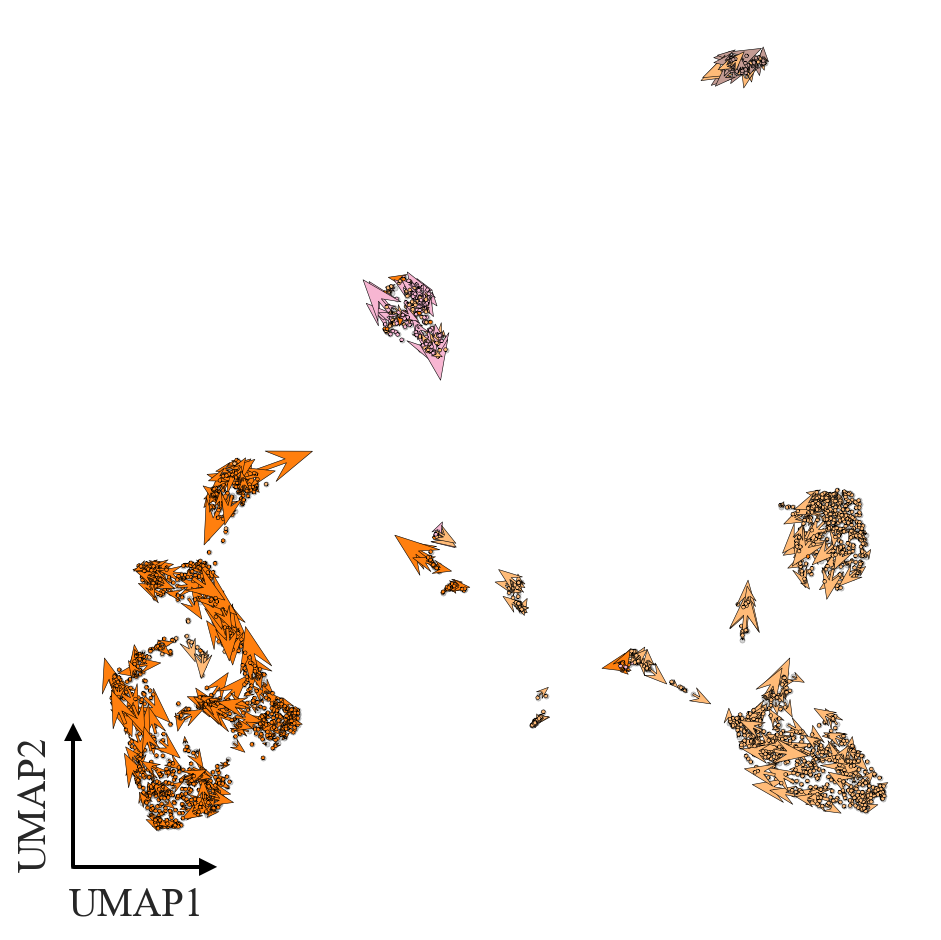

In [16]:
oracle.get_cluster_specific_TFdict_from_Links(links_object = links)
oracle.fit_GRN_for_simulation(alpha = 10, use_cluster_specific_TFdict = True)
goi = "RORC"
sc.pl.umap(oracle.adata, color = [goi, oracle.cluster_column_name], layer = "imputed_count", use_raw = False, cmap = "viridis")
oracle.simulate_shift(perturb_condition = {goi: 0.0}, n_propagation = 3)
oracle.estimate_transition_prob(n_neighbors = 200, knn_random = True, sampled_fraction = 1)
oracle.calculate_embedding_shift(sigma_corr = 0.05)

fig, ax = plt.subplots(figsize = (6, 6))
oracle.plot_quiver_random(scale = 20, ax = ax)
ax = plt.gca()
ax.set_xlabel("UMAP1", fontsize = 18)
ax.set_ylabel("UMAP2", fontsize = 18)


x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
x_range = x_max - x_min
y_range = y_max - y_min
aspect_ratio = (fig.get_size_inches()[0] / fig.get_size_inches()[1]) * (y_range / x_range)
dx = x_range * 0.15 * aspect_ratio
dy = y_range * 0.15 * aspect_ratio
head_width = dy * 0.1
head_length = dx * 0.1
ax.arrow(x_min, y_min, dx, 0, head_width = head_width, head_length = head_length, fc = "black", ec = "black", linewidth = 1.5)
ax.arrow(x_min, y_min, 0, dy, head_width = head_width, head_length = head_length, fc = "black", ec = "black", linewidth = 1.5)


label_offset = dx * 0.15
ax.text(x_min + dx / 2, y_min - label_offset, "UMAP1", ha = "center", va = "top", fontsize = 18)
ax.text(x_min - label_offset, y_min + dy / 2, "UMAP2", rotation = 90, ha = "right", va = "center", fontsize = 18)
plt.tight_layout()
plt.savefig("/home/jsl/YBR/Ex2/Figure/Supplement-Figure13-c.png", dpi = 600, bbox_inches = "tight")
plt.show()